In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from experiments import evaluation as ev

In [2]:
df = ev.build_results("results")

/Users/s.franke/Development/master_clean/experiments/evaluation.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df.apply(calc_row, axis=1, args=(err_col, conf_col))


In [3]:
df.to_csv("results_5.csv", index=False)

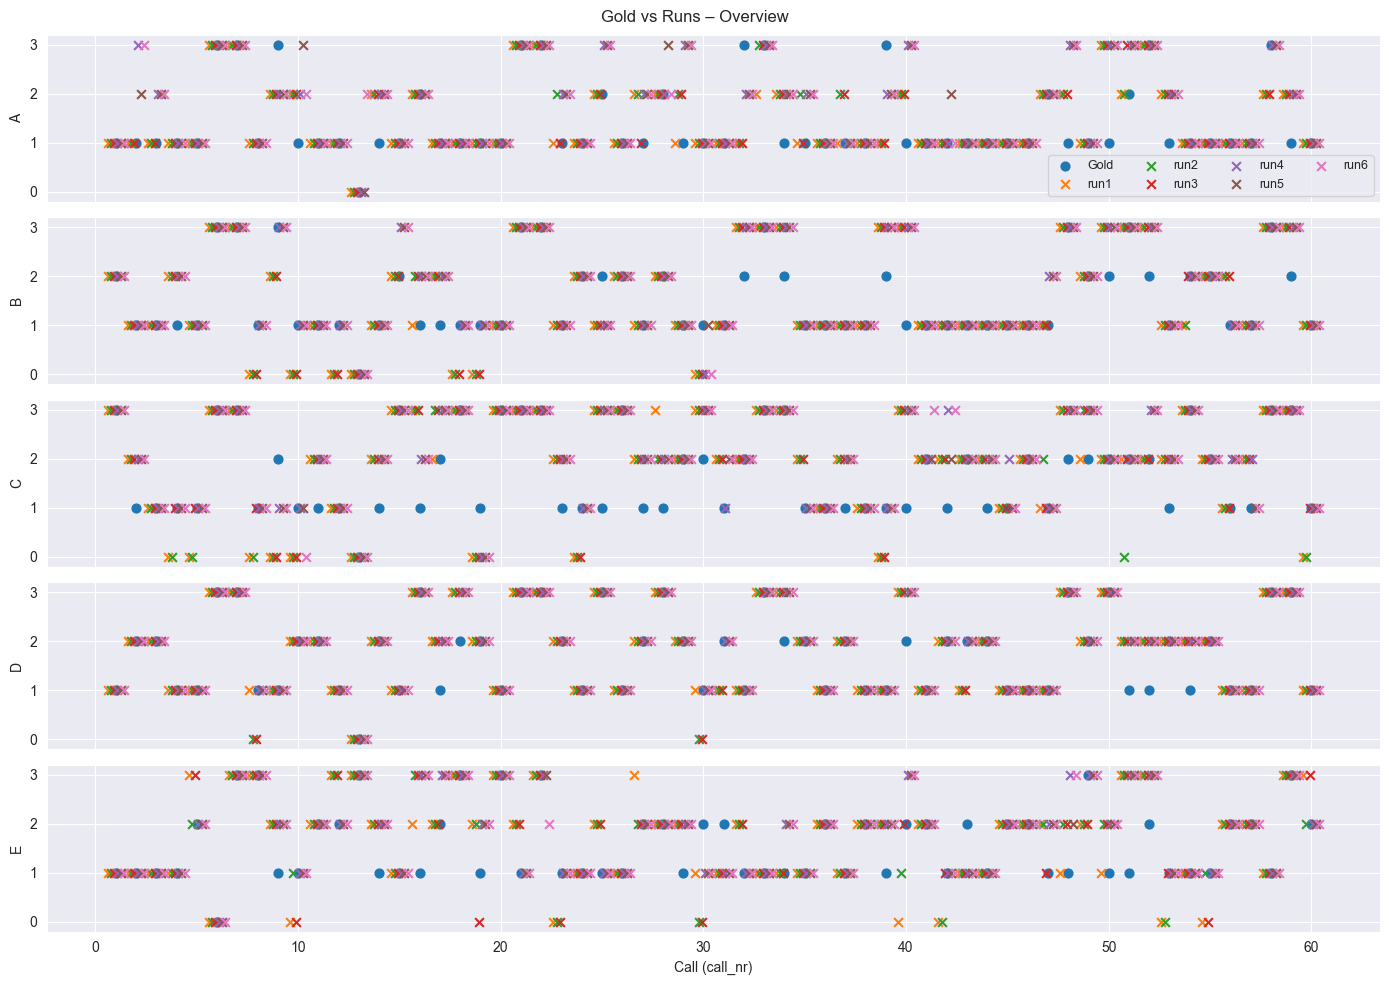

In [4]:
long_df = ev.wide_to_long_runs(df)
plt = ev.plot_runs_vs_gold_big(long_df, title="Gold vs Runs – Overview")

plt.savefig("Experiment_5.png", dpi=600, bbox_inches="tight")

In [31]:
long_err = ev.errors_wide_to_long(df)
summary = ev.summarize_errors(long_err)
summary

,type,run,domain,N,mean,median,sum,rmse
0,conf_error,1,A,60,0.468000,0.280,28.08,0.641374
1,conf_error,1,B,60,0.355833,0.220,21.35,0.513009
2,conf_error,1,C,60,0.460333,0.380,27.62,0.565632
3,conf_error,1,D,60,0.296000,0.220,17.76,0.374255
4,conf_error,1,E,60,0.523333,0.450,31.40,0.607402
5,conf_error,2,A,60,0.461667,0.280,27.70,0.613520
6,conf_error,2,B,60,0.374500,0.220,22.47,0.531142
7,conf_error,2,C,60,0.461667,0.400,27.70,0.561011
8,conf_error,2,D,60,0.288500,0.220,17.31,0.371266
9,conf_error,2,E,60,0.512167,0.420,30.73,0.623564


In [32]:
mean_conf_error_matrix = (
    summary[summary["type"] == "conf_error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_conf_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.468000,0.355833,0.460333,0.296000,0.523333
2,0.461667,0.374500,0.461667,0.288500,0.512167
3,0.462167,0.366333,0.455000,0.299833,0.511167
4,0.482833,0.341833,0.448333,0.292667,0.447667
5,0.499833,0.349667,0.430833,0.290833,0.432667
6,0.488833,0.348000,0.438667,0.291500,0.450667


In [33]:
mean_error_matrix = (
    summary[summary["type"] == "error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.366667,0.350000,0.533333,0.150000,0.483333
2,0.400000,0.366667,0.600000,0.183333,0.450000
3,0.366667,0.350000,0.483333,0.183333,0.450000
4,0.450000,0.250000,0.433333,0.116667,0.333333
5,0.483333,0.233333,0.400000,0.116667,0.316667
6,0.483333,0.250000,0.450000,0.116667,0.366667


In [34]:
total_per_run = (
    long_err
    .groupby(["type", "run"], as_index=False)
    .agg(
        N=("value", "count"),
        mean=("value", "mean"),
        sum=("value", "sum"),
        max=("value", "max"),
    )
    .sort_values(["type", "run"])
)
total_per_run

,type,run,N,mean,sum,max
0,conf_error,1,300,0.420700,126.21,2.16
1,conf_error,2,300,0.419700,125.91,1.90
2,conf_error,3,300,0.418900,125.67,1.90
3,conf_error,4,300,0.402667,120.80,1.94
4,conf_error,5,300,0.400767,120.23,1.94
5,conf_error,6,300,0.403533,121.06,1.94
6,error,1,300,0.376667,113.00,3.00
7,error,2,300,0.400000,120.00,3.00
8,error,3,300,0.366667,110.00,3.00
9,error,4,300,0.316667,95.00,2.00


In [35]:
df_totals = ev.total_error_per_run(df)
df_totals

,run,sum_error,sum_conf_error
0,1,113,126.21
1,2,120,125.91
2,3,110,125.67
3,4,95,120.80
4,5,93,120.23
5,6,100,121.06


In [36]:
df_cat = ev.error_summary_per_category(df)
df_cat

,domain,mean_error,sum_error,mean_conf_error,sum_conf_error
0,A,0.425000,153,0.477222,171.80
1,B,0.300000,108,0.356028,128.17
2,C,0.483333,174,0.449139,161.69
3,D,0.144444,52,0.293222,105.56
4,E,0.400000,144,0.479611,172.66


In [22]:
(df == 9).sum()

A                 0
A_1               0
A_1_conf          0
A_1_conf_error    0
A_1_error         0
                 ..
E_5_error         0
E_6               0
E_6_conf          0
E_6_conf_error    0
E_6_error         0
Length: 125, dtype: int64

In [24]:
import tiktoken

OUTPUT_CONTRACT_DEFAULT = """
Return ONLY valid JSON (no markdown, no commentary).

Schema:
{
  "A": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "B": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "C": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "D": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "E": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>}
}
""".strip()

guidelines = Path("guidelines/a_guidelines.md").read_text(encoding="utf-8")

text = guidelines + "\n\n" + OUTPUT_CONTRACT_DEFAULT

## Token zählen: 


encoding = tiktoken.get_encoding("o200k_base")

tokens = encoding.encode(text)

print("GPT 5.2:", len(tokens))
import anthropic
import pandas as pd
import requests
from dotenv import load_dotenv
from anthropic import Anthropic
import os

load_dotenv()
os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")
client = anthropic.Anthropic()

response = client.messages.count_tokens(
    model="claude-opus-4-6",
    messages=[{"role": "user", "content": text}],
)

print(response.json())

GPT 5.2: 568
{"input_tokens":655}


/var/folders/9k/bqn5d5t90kl0x7z66fx4d0cw0000gn/T/ipykernel_7564/3563792046.py:44: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  print(response.json())


In [26]:
670 * 5

3350

In [5]:
df.sum

,A,A_1,A_1_conf,A_1_conf_error,A_1_error,A_2,A_2_conf,A_2_conf_error,A_2_error,A_3,...,E_4_conf_error,E_4_error,E_5,E_5_conf,E_5_conf_error,E_5_error,E_6,E_6_conf,E_6_conf_error,E_6_error
call_nr,,,,,,,,,,,,,,,,,,,,,
1,1,1,0.78,0.22,0,1,0.74,0.26,0,1,...,0.20,0,1,0.70,0.30,0,1,0.80,0.20,0
2,1,1,0.62,0.38,0,1,0.70,0.30,0,1,...,0.30,0,1,0.70,0.30,0,1,0.70,0.30,0
3,1,1,0.62,0.38,0,1,0.72,0.28,0,1,...,0.40,0,1,0.60,0.40,0,1,0.70,0.30,0
4,1,1,0.72,0.28,0,1,0.62,0.38,0,1,...,0.30,0,1,0.70,0.30,0,1,0.70,0.30,0
5,1,1,0.62,0.38,0,1,0.62,0.38,0,1,...,0.40,0,2,0.62,0.38,0,2,0.62,0.38,0
6,3,3,0.72,0.28,0,3,0.72,0.28,0,3,...,0.60,0,0,0.40,0.60,0,0,0.40,0.60,0
7,3,3,0.78,0.22,0,3,0.72,0.28,0,3,...,0.08,0,3,0.92,0.08,0,3,0.92,0.08,0
8,1,1,0.62,0.38,0,1,0.74,0.26,0,1,...,0.28,0,3,0.72,0.28,0,3,0.72,0.28,0
9,3,2,0.72,2.16,3,2,0.72,2.16,3,2,...,0.72,1,2,0.72,0.72,1,2,0.72,0.72,1


In [6]:
import pandas as pd

DOMAINS = ["A", "B", "C", "D", "E"]
RUN = 5

# Gold-Spalten
gold_cols = DOMAINS

# Run-Spalten
run_cols = [
    f"{d}_{RUN}" for d in DOMAINS
] + [
    f"{d}_{RUN}_error" for d in DOMAINS
] + [
    f"{d}_{RUN}_conf" for d in DOMAINS
] + [
    f"{d}_{RUN}_conf_error" for d in DOMAINS
]

cols = gold_cols + run_cols

df_run5 = df[cols].copy()

print(df_run5.head())

         A  B  C  D  E  A_5  B_5  C_5  D_5  E_5  ...  A_5_conf  B_5_conf  \
call_nr                                          ...                       
1        1  2  3  1  1    1    2    3    1    1  ...      0.60      0.72   
2        1  1  1  2  1    2    1    2    2    1  ...      0.72      0.85   
3        1  1  1  2  1    2    1    1    2    1  ...      0.50      0.80   
4        1  1  1  1  1    1    2    1    1    1  ...      0.60      0.72   
5        1  1  1  1  2    1    1    1    1    2  ...      0.60      0.60   

         C_5_conf  D_5_conf  E_5_conf  A_5_conf_error  B_5_conf_error  \
call_nr                                                                 
1            0.82      0.60      0.70            0.40            0.28   
2            0.55      0.85      0.70            0.72            0.15   
3            0.50      0.60      0.60            0.50            0.20   
4            0.70      0.60      0.70            0.40            0.72   
5            0.60      0.70  

In [13]:
df_run5["A_5_error"].value_counts()

A_5_error
0    39
1    13
3     8
Name: count, dtype: int64

In [14]:
df_run5["B_5_error"].value_counts()

B_5_error
0    47
1    11
2     1
3     1
Name: count, dtype: int64

In [15]:
df_run5["C_5_error"].value_counts()

C_5_error
0    38
1    19
3     2
2     1
Name: count, dtype: int64

In [16]:
df_run5["D_5_error"].value_counts()

D_5_error
0    53
1     7
Name: count, dtype: int64

In [17]:
df_run5["E_5_error"].value_counts()

E_5_error
0    43
1    12
2     3
3     2
Name: count, dtype: int64

In [18]:
df["E_5_error"].value_counts()

E_5_error
0    43
1    12
2     3
3     2
Name: count, dtype: int64

In [21]:
df["E_1_error"].value_counts()

E_1_error
0    34
1    20
2     3
3     2
4     1
Name: count, dtype: int64

Error counts for A_1_error:
A_1_error
0    46
1     8
3     4
6     2
Name: count, dtype: int64


Error counts for A_2_error:
A_2_error
0    43
1    12
3     3
6     2
Name: count, dtype: int64


Error counts for A_3_error:
A_3_error
0    45
1    10
3     3
6     2
Name: count, dtype: int64


Error counts for A_4_error:
A_4_error
0    41
1    11
3     8
Name: count, dtype: int64


Error counts for A_5_error:
A_5_error
0    39
1    13
3     8
Name: count, dtype: int64


Error counts for B_1_error:
B_1_error
0    41
1    15
3     2
2     2
Name: count, dtype: int64


Error counts for B_2_error:
B_2_error
0    40
1    16
3     2
2     2
Name: count, dtype: int64


Error counts for B_3_error:
B_3_error
0    41
1    16
3     2
2     1
Name: count, dtype: int64


Error counts for B_4_error:
B_4_error
0    46
1    12
2     1
3     1
Name: count, dtype: int64


Error counts for B_5_error:
B_5_error
0    47
1    11
2     1
3     1
Name: count, dtype: int64


Error counts for C_1_error:
C_1_erro

In [25]:
df_5 = pd.read_csv("results/run_5.csv")

In [26]:
df_5

,file,call_nr,severity_A,confidence_A,findings_A,error_A,severity_B,confidence_B,findings_B,error_B,...,findings_C,error_C,severity_D,confidence_D,findings_D,error_D,severity_E,confidence_E,findings_E,error_E
0,Notruf_1,1,1,0.60,"[""patient speaks in full sentences throughout ...",NaN,2,0.72,"[""Caller reports difficulty breathing ('ich kr...",NaN,...,"[""75-year-old male with acute onset chest pain...",NaN,1,0.60,"[""Patient is responsive and communicates coher...",NaN,1,0.70,"[""No trauma, accident, or external injury repo...",NaN
1,Notruf_2,2,2,0.72,"[""Patient has slurred/garbled speech ('verwasc...",NaN,1,0.85,"[""Caller explicitly states father is breathing...",NaN,...,"[""Patient has known hypertension (blood pressu...",NaN,2,0.85,"[""Verwaschene Sprache seit ca. einer Stunde"", ...",NaN,1,0.70,"[""No trauma or external injury reported"", ""No ...",NaN
2,Notruf_3,3,2,0.50,"[""Patient lying on street, reduced consciousne...",NaN,1,0.80,"[""Caller explicitly states no breathing proble...",NaN,...,"[""Man lying on street, responsive when spoken ...",NaN,2,0.60,"[""Man lying on the street, apparently sleeping...",NaN,1,0.60,"[""Man lying on street, responsive when address...",NaN
3,Notruf_4,4,1,0.60,"[""caller speaks in short but intelligible phra...",NaN,2,0.72,"[""caller reports difficulty breathing ('krieg ...",NaN,...,"[""Caller denies dizziness when asked about cir...",NaN,1,0.60,"[""Patient is responsive and able to communicat...",NaN,1,0.70,"[""No trauma or accident reported"", ""No externa...",NaN
4,Notruf_5,5,1,0.60,"[""patient is conscious and screaming, indicati...",NaN,1,0.60,"[""caller reports wife occasionally breathes he...",NaN,...,"[""Patient is conscious and responsive"", ""No ci...",NaN,1,0.70,"[""Patient is conscious and responsive"", ""No ne...",NaN,2,0.62,"[""Frau in der 34. Schwangerschaftswoche mit ak...",NaN
5,Notruf_6,6,3,0.72,"[""Patient found unresponsive in bed, described...",NaN,3,0.90,"[""Patient is not breathing ('die atmet nicht')...",NaN,...,"[""Patient appears lifeless, found unresponsive...",NaN,3,0.72,"[""Patient found unresponsive in bed, described...",NaN,0,0.40,"[""Patient found unresponsive in bed, no breath...",NaN
6,Notruf_7,7,3,0.82,"[""Stab wound to the neck reported"", ""Patient m...",NaN,3,0.92,"[""Patient has obvious difficulty breathing ('s...",NaN,...,"[""Stab wound to the neck with active bleeding""...",NaN,3,0.85,"[""Patient ist 'sehr eingetrübt' (stark reduzie...",NaN,3,0.92,"[""Messerstichverletzung am Hals"", ""aktive Blut...",NaN
7,Notruf_8,8,1,0.70,"[""caller speaks in full sentences throughout t...",NaN,1,0.72,"[""caller speaks in full sentences throughout t...",NaN,...,"[""Patient fell from a ladder (~3 meters height...",NaN,1,0.50,"[""Patient fell from a ladder approximately 3 m...",NaN,3,0.72,"[""Fall from ladder attempting to reach roof, e...",NaN
8,Notruf_9,9,2,0.72,"[""Patient ate nut cake shortly before symptom ...",NaN,3,0.82,"[""Patient has difficulty breathing after eatin...",NaN,...,"[""caller mentions patient is red in the face (...",NaN,1,0.60,"[""Patient is responsive and able to speak"", ""N...",NaN,2,0.72,"[""Patient consumed nut cake shortly before sym...",NaN
9,Notruf_10,10,3,0.72,"[""Patient speaks slurred/muffled ('nuschelt so...",NaN,1,0.60,"[""No breathing difficulties mentioned by calle...",NaN,...,"[""Patient is conscious"", ""No chest pain, pulse...",NaN,2,0.82,"[""Patient is conscious but confused since waki...",NaN,1,0.70,"[""No trauma, accident, or external injury mech...",NaN


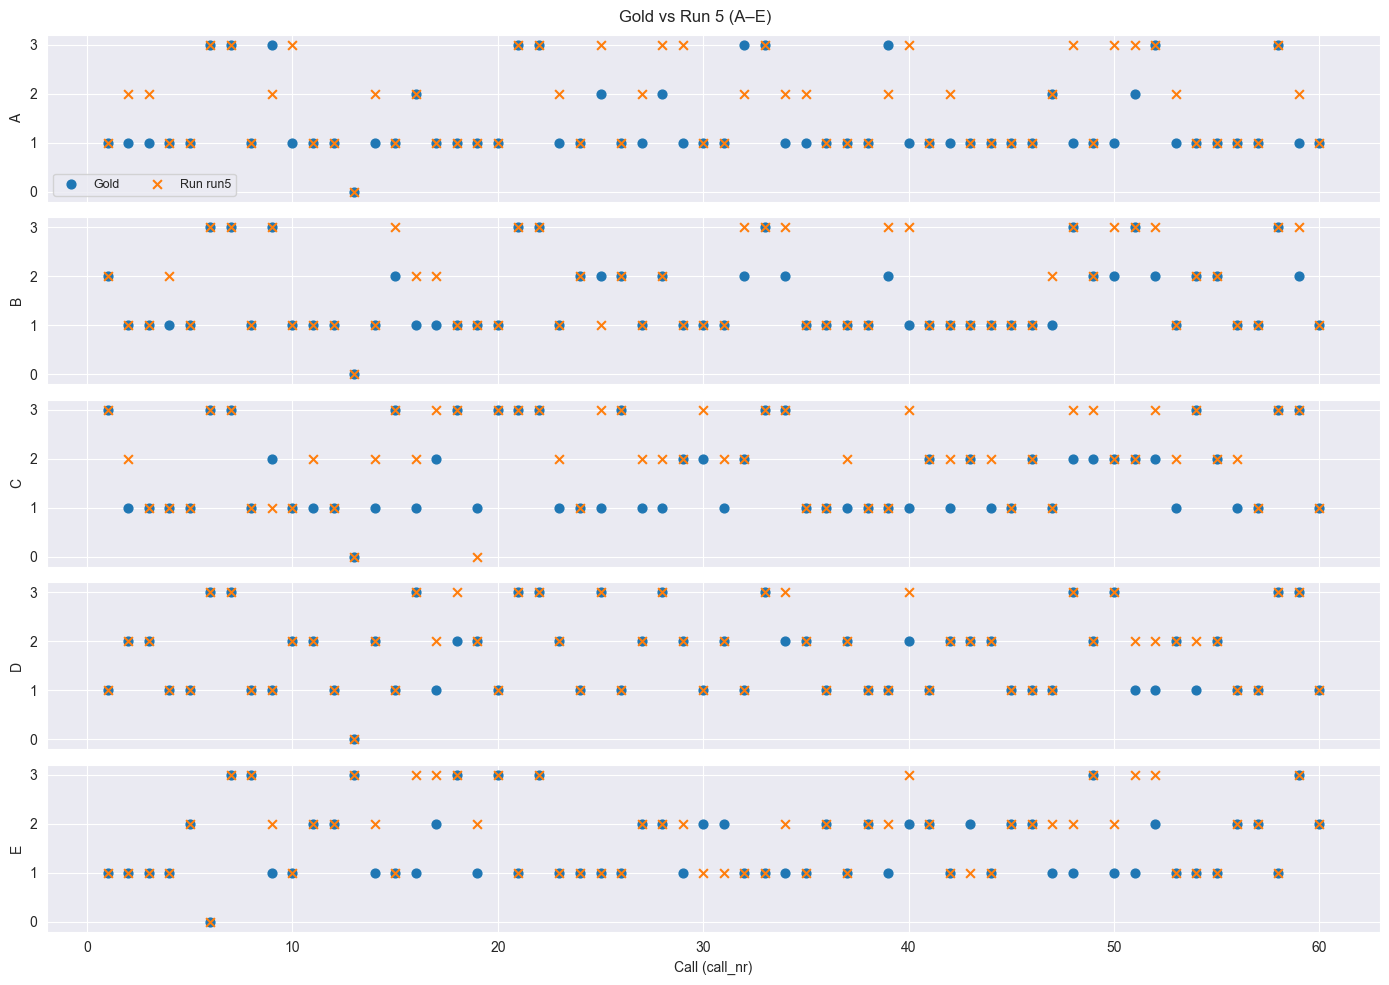

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

DOMAINS = ["A", "B", "C", "D", "E"]

def plot_run_vs_gold_big(
    long_df: pd.DataFrame,
    run_to_show: int,
    title: str | None = None,
):
    """
    Overview plot for ONE run:
    - 5 lines (A..E)
    - x-axis: call_nr
    - Gold as points
    - Predictions for the selected run as X
    """
    # Filter auf den gewünschten Run
    df_run = long_df[long_df["run"] == run_to_show].copy()
    if df_run.empty:
        available = sorted(long_df["run"].dropna().unique().tolist())
        raise ValueError(f"run_to_show={run_to_show} not found. Available runs: {available}")

    if title is None:
        title = f"Gold vs Run {run_to_show} (A–E)"

    fig, axes = plt.subplots(5, 1, sharex=True, figsize=(14, 10))

    for i, d in enumerate(DOMAINS):
        ax = axes[i]

        # Domain-Subset
        sub = df_run[df_run["domain"] == d].copy().dropna(subset=["call_nr"])

        # Gold: (einmal pro call) – beim Run-Subset reicht drop_duplicates auf call_nr
        gold_per_call = (
            sub.dropna(subset=["gold"])
               .sort_values(["call_nr"])
               .drop_duplicates(subset=["call_nr"])[["call_nr", "gold"]]
        )
        ax.scatter(gold_per_call["call_nr"], gold_per_call["gold"], s=40, label="Gold")

        # Predictions (nur dieser Run)
        pred = sub.dropna(subset=["pred"])
        ax.scatter(pred["call_nr"], pred["pred"], marker="x", s=40, label=f"Run {run_to_show}")

        ax.set_ylabel(d)
        ax.set_ylim(-0.2, 3.2)
        ax.grid(True)

        if i == 0:
            ax.legend(ncol=2, fontsize=9)

    axes[-1].set_xlabel("Call (call_nr)")

    plt.suptitle(title)
    plt.tight_layout()
    

    return fig

plt = plot_run_vs_gold_big(long_df, long_df_2, run_to_show="run5", title="Gold vs Run 5 (A–E)")
plt.savefig("Experiment_5.png", dpi=600, bbox_inches="tight")


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

DOMAINS = ["A", "B", "C", "D", "E"]

def plot_two_runs_vs_gold_big(
    long_df1: pd.DataFrame,
    long_df2: pd.DataFrame,
    run1,
    run2,
    label1="Run A",
    label2="Run B",
    title: str | None = None,
):

    df1 = long_df1[long_df1["run"] == run1].copy()
    df2 = long_df2[long_df2["run"] == run2].copy()

    if df1.empty:
        raise ValueError(f"{run1} not found in long_df1")

    if df2.empty:
        raise ValueError(f"{run2} not found in long_df2")

    if title is None:
        title = f"Gold vs {run1} vs {run2}"

    fig, axes = plt.subplots(5, 1, sharex=True, figsize=(14, 10))

    for i, d in enumerate(DOMAINS):
        ax = axes[i]

        sub1 = df1[df1["domain"] == d].copy().dropna(subset=["call_nr"])
        sub2 = df2[df2["domain"] == d].copy().dropna(subset=["call_nr"])

        # Gold (aus erstem DF)
        gold_per_call = (
            sub1.dropna(subset=["gold"])
                .sort_values(["call_nr"])
                .drop_duplicates(subset=["call_nr"])[["call_nr", "gold"]]
        )

        ax.scatter(
            gold_per_call["call_nr"],
            gold_per_call["gold"],
            s=40,
            color="black",
            label="Gold"
        )

        # Run 1
        pred1 = sub1.dropna(subset=["pred"])
        ax.scatter(
            pred1["call_nr"],
            pred1["pred"],
            marker="x",
            s=50,
            color="tab:blue",
            label=label1
        )

        # Run 2
        pred2 = sub2.dropna(subset=["pred"])
        ax.scatter(
            pred2["call_nr"],
            pred2["pred"],
            marker="x",
            s=50,
            color="tab:red",
            label=label2
        )

        ax.set_ylabel(d)
        ax.set_ylim(-0.2, 3.2)
        ax.grid(True)

        if i == 0:
            ax.legend(ncol=3, fontsize=9)

    axes[-1].set_xlabel("Call (call_nr)")

    plt.suptitle(title)
    plt.tight_layout()

    return fig

In [35]:
long_df_2= pd.read_csv("long_results_4.csv")

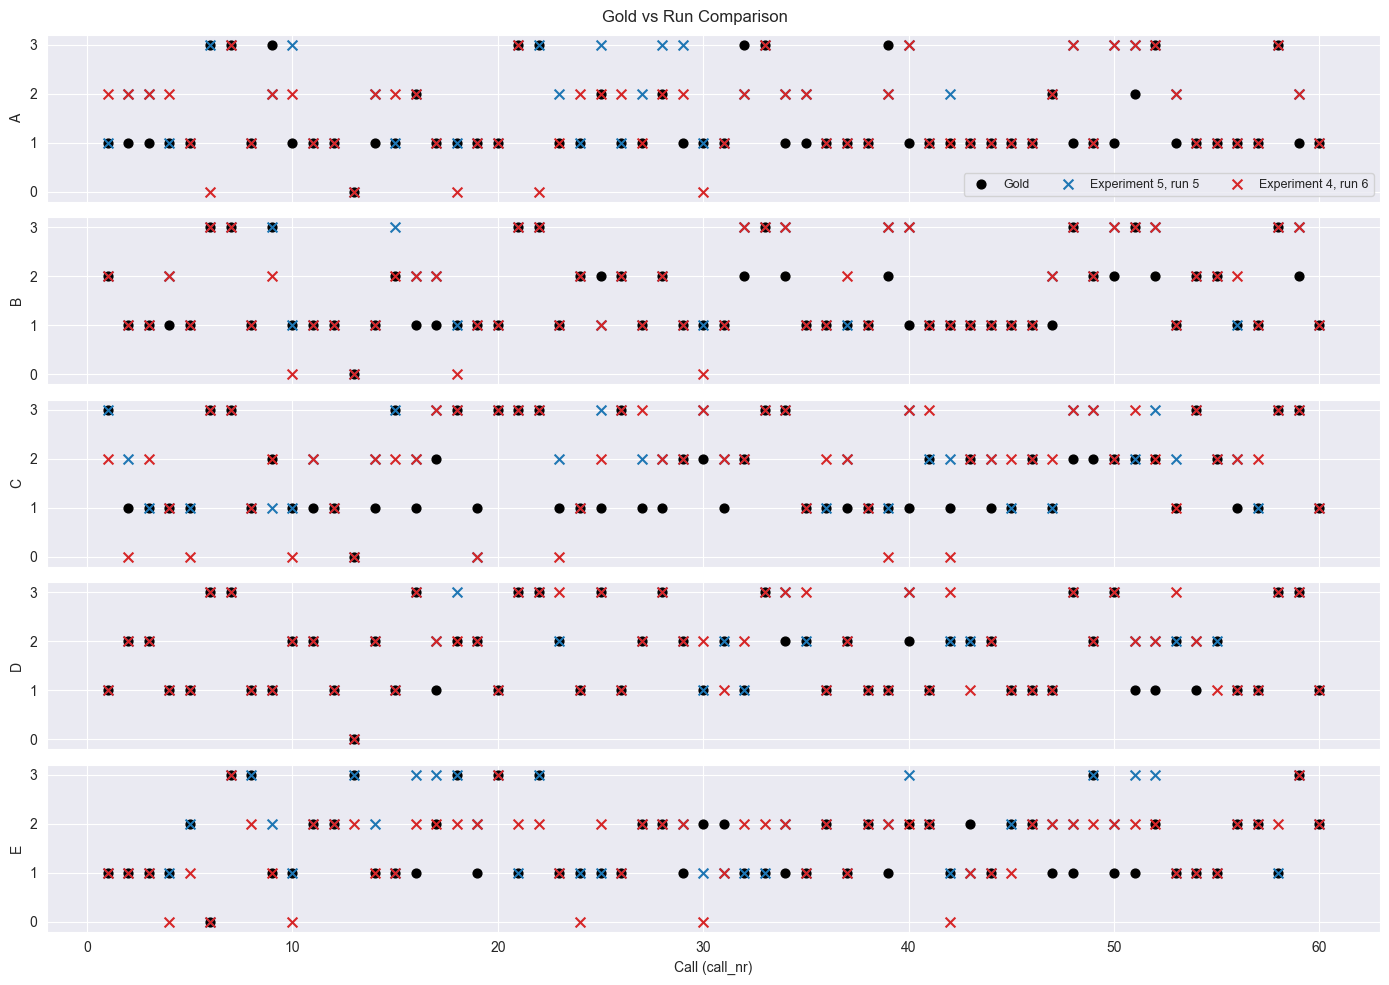

In [36]:
fig = plot_two_runs_vs_gold_big(
    long_df,
    long_df_2,
    run1="run5",
    run2="run6",
    label1="Experiment 5, run 5",
    label2="Experiment 4, run 6",
    title="Gold vs Run Comparison"
)

fig.savefig("model_comparison.png", dpi=600, bbox_inches="tight")

In [41]:
df_run5["A_5_conf"]

np.float64(44.72999999999999)